# Δ-learning: tree baseline + deep learning on residuals

**Idea:** fit a **tree ensemble on Morgan fingerprints** (fast, strong baseline from the README leaderboard), then train **PyG GNN** and a small **Hugging Face** transformer on the **residual** `delta = y - y_tree` so the DL models specialize in what the fingerprint model misses.

Final test prediction: `y_hat = y_tree + delta_dl`.

**Requires:** `pip install openadnet[dl]` (PyTorch, PyG, transformers). The first `load_data` import may download the training CSV from Hugging Face.

**Runtime:** a random subset of rows (`N_MAX`) keeps training tractable in a notebook; increase for sharper metrics.

In [11]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from rdkit import Chem
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

_REPO = Path.cwd().resolve()
if not (_REPO / "src" / "baseline.py").exists():
    _REPO = _REPO.parent
sys.path.insert(0, str(_REPO / "src"))

from baseline import BaselineCVConfig, make_regressor_pipeline, prepare_training_data
from delta_learning import combine_predictions, compute_delta
from features_data import build_descriptor_matrix
from load_data import train

import torch
from models import GNNRegressor, HuggingFaceRegressor
from models.data import GraphRegressionDataset, SmilesRegressionDataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 0
Y_COL = "pEC50"
DESCRIPTOR = "morgan_r1_count_1024"
N_MAX = 3200
TEST_SIZE = 0.2
GNN_EPOCHS = 40
HF_EPOCHS = 0
HF_MODEL = "hf-internal-testing/tiny-random-bert"

## Load data and subsample

Aligned **SMILES**, **fingerprints**, and **pEC50** after `prepare_training_data`.

In [12]:
mols = list(train["SMILES"].apply(Chem.MolFromSmiles))
y_all, mols_f, mask = prepare_training_data(train, mols, y_col=Y_COL)
train_f = train.loc[mask].reset_index(drop=True)
X_fp = build_descriptor_matrix(DESCRIPTOR, mols_f).astype(np.float64)
smiles_all = train_f["SMILES"].astype(str).tolist()

rng = np.random.RandomState(RANDOM_STATE)
n = len(y_all)
take = rng.choice(n, size=min(N_MAX, n), replace=False)
y = y_all[take]
X_fp = X_fp[take]
mols_f = [mols_f[i] for i in take]
smiles_all = [smiles_all[i] for i in take]

print(f"Subsample: {len(y)} rows | {DESCRIPTOR} shape {X_fp.shape}")


Subsample: 3200 rows | morgan_r1_count_1024 shape (3200, 1024)


## Train / test split (same indices for fingerprints, graphs, SMILES)

In [13]:
ix = np.arange(len(y))
ix_train, ix_test = train_test_split(
    ix, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
y_train, y_test = y[ix_train], y[ix_test]
X_tr, X_te = X_fp[ix_train], X_fp[ix_test]
smi_tr = [smiles_all[i] for i in ix_train]
smi_te = [smiles_all[i] for i in ix_test]

print("train", len(ix_train), "test", len(ix_test))

train 2560 test 640


## Tree baseline (HistGradientBoosting on fingerprints)

Same pipeline naming as `baseline.make_regressor_pipeline("hgb", ...)`.

In [14]:
cfg = BaselineCVConfig(y_col=Y_COL, model_random_state=RANDOM_STATE)
tree_est = HistGradientBoostingRegressor(max_iter=200, random_state=cfg.model_random_state)
tree_pipe = make_regressor_pipeline("hgb", tree_est)
tree_pipe.fit(X_tr, y_train)

y_tree_tr = tree_pipe.predict(X_tr)
y_tree_te = tree_pipe.predict(X_te)

delta_tr = compute_delta(y_train, y_tree_tr)
delta_te = compute_delta(y_test, y_tree_te)

rmse = lambda a, b: float(np.sqrt(mean_squared_error(a, b)))
print("Test RMSE — tree only:", rmse(y_test, y_tree_te))
print("Train |delta| mean:", float(np.mean(np.abs(delta_tr))))

Test RMSE — tree only: 0.7372133247827624
Train |delta| mean: 0.22491259094908464


## DL on residuals: GNN (PyG) and Hugging Face

`GraphRegressionDataset` / `SmilesRegressionDataset` use **delta** as the regression target. Predictions are mapped back with `combine_predictions`.

In [15]:
ds_gnn_tr = GraphRegressionDataset(smi_tr, delta_tr.reshape(-1, 1))
ds_gnn_te = GraphRegressionDataset(smi_te, delta_te.reshape(-1, 1))

gnn = GNNRegressor(
    n_tasks=1,
    hidden_dim=64,
    num_layers=3,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)
gnn.fit(ds_gnn_tr, epochs=GNN_EPOCHS, batch_size=32, show_progress=False)
delta_gnn_te = gnn.predict(ds_gnn_te, show_progress=False).ravel()
y_gnn_te = combine_predictions(y_tree_te, delta_gnn_te)

print("Test RMSE — tree + GNN delta:", rmse(y_test, y_gnn_te))

Test RMSE — tree + GNN delta: 0.7372899712320206


In [16]:
try:
    hf = HuggingFaceRegressor(HF_MODEL, n_tasks=1, max_length=64)
except OSError as e:
    raise RuntimeError(f"Hugging Face hub / model load failed: {e}") from e

ds_hf_tr = SmilesRegressionDataset(smi_tr, delta_tr.reshape(-1, 1))
ds_hf_te = SmilesRegressionDataset(smi_te, delta_te.reshape(-1, 1))

hf.fit(ds_hf_tr, epochs=HF_EPOCHS, batch_size=16, show_progress=False)
delta_hf_te = hf.predict(ds_hf_te, show_progress=False).ravel()
y_hf_te = combine_predictions(y_tree_te, delta_hf_te)

print("Test RMSE — tree + HF delta:", rmse(y_test, y_hf_te))

Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: hf-internal-testing/tiny-random-bert
Key                                        | Status     |                                                                                     
-------------------------------------------+------------+-------------------------------------------------------------------------------------
cls.seq_relationship.bias                  | UNEXPECTED |                                                                                     
cls.predictions.transform.dense.bias       | UNEXPECTED |                                                                                     
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |                                                                                     
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |                                                                                     
qa_outputs.weight                          | UNEXPECTED |

Test RMSE — tree + HF delta: 0.7373792354657817


### Optional: `DeltaLearningRegressor` (sklearn on the same residuals)

The helper class in `delta_learning.py` fits a **second** regressor on `delta` with the same `(X, y, y_baseline)` pattern—here on **fingerprints** (another tree). Compare to the GNN/HF heads that see structure / SMILES.

In [17]:
from delta_learning import DeltaLearningRegressor

dl_sk = DeltaLearningRegressor(
    HistGradientBoostingRegressor(max_iter=150, random_state=RANDOM_STATE)
)
dl_sk.fit(X_tr, y_train, y_tree_tr)
y_sk_te = dl_sk.predict(X_te, y_tree_te)
print("Test RMSE — DeltaLearningRegressor (2nd HGB on fp, same as residual boost):", rmse(y_test, y_sk_te))

Test RMSE — DeltaLearningRegressor (2nd HGB on fp, same as residual boost): 0.7366807829790374


## Summary table and plots

,model,test_rmse
0,Δ-learning + 2nd HGB (sklearn API),0.736681
1,HGB fingerprint (baseline),0.737213
2,Δ-learning + GNN,0.737290
3,Δ-learning + HF,0.737379


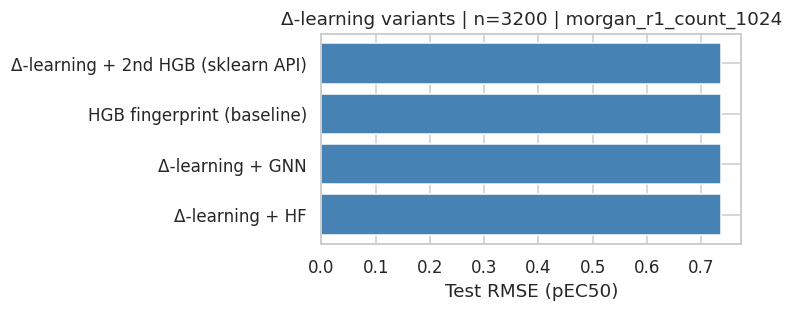

In [18]:
summary = pd.DataFrame(
    [
        {"model": "HGB fingerprint (baseline)", "test_rmse": rmse(y_test, y_tree_te)},
        {"model": "Δ-learning + GNN", "test_rmse": rmse(y_test, y_gnn_te)},
        {"model": "Δ-learning + HF", "test_rmse": rmse(y_test, y_hf_te)},
        {"model": "Δ-learning + 2nd HGB (sklearn API)", "test_rmse": rmse(y_test, y_sk_te)},
    ]
).sort_values("test_rmse").reset_index(drop=True)
display(summary)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(summary["model"], summary["test_rmse"], color="steelblue")
ax.set_xlabel("Test RMSE (pEC50)")
ax.invert_yaxis()
ax.set_title(f"Δ-learning variants | n={len(y)} | {DESCRIPTOR}")
plt.tight_layout()
plt.show()

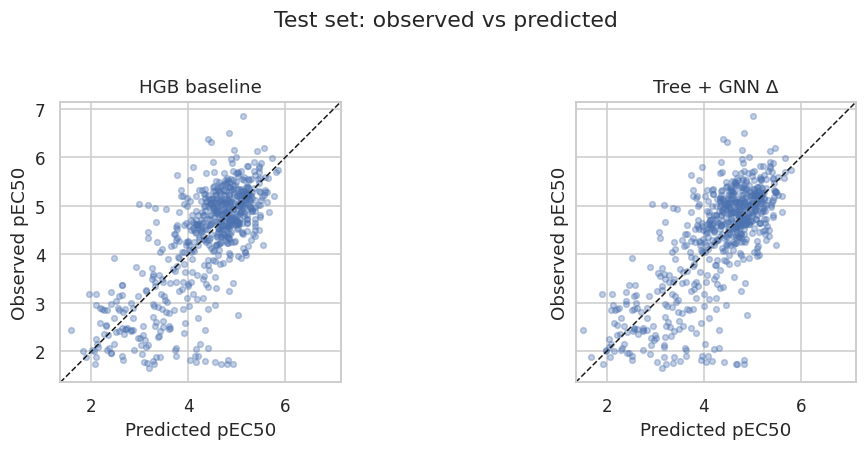

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
lims = (float(y_test.min()) - 0.3, float(y_test.max()) + 0.3)
for ax, (title, yp) in zip(
    axes,
    [
        ("HGB baseline", y_tree_te),
        ("Tree + GNN Δ", y_gnn_te),
    ],
):
    ax.scatter(yp, y_test, alpha=0.35, s=14)
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Predicted pEC50")
    ax.set_ylabel("Observed pEC50")
    ax.set_title(title)
plt.suptitle("Test set: observed vs predicted", y=1.02)
plt.tight_layout()
plt.show()

### Notes

- **Leakage:** the tree is fit only on the train split; **test** baselines `y_tree_te` are honest inputs for `combine_predictions`. (For rigorous nested CV you would swap folds and regenerate baselines per fold.)
- **Second HGB on Δ** often tracks the same information as the first HGB on fingerprints; **GNN / SMILES** can pick up **graph** patterns the Morgan baseline underfits.
- Increase **`N_MAX`**, **`GNN_EPOCHS`**, and swap **`HF_MODEL`** for a chemistry LM for stronger DL residuals (longer GPU time).